# **Progetto - Cross Selling Polizze Assicurative**
Il cliente è una compagnia di assicurazioni che ha fornito un'assicurazione sanitaria ai suoi clienti, adesso hanno bisogno del tuo aiuto per costruire un modello predittivo in grado di prevedere se gli assicurati dell'anno passato potrebbero essere interessati ad acquistare anche un'assicurazione per il proprio veicolo.  
Il dataset è composto dalle seguenti proprietà:

- **id**: id univoco dell'acquirente.
- **Gender**: sesso dell'acquirente.
- **Age**: età dell'acquirente.
- **Driving_License**: 1 se l'utente ha la patente di guida, 0 altrimenti.
- **Region_Code**: codice univoco della regione dell'acquirente.
- **Previously_Insured**: 1 se l'utente ha già un veicolo assicurato, 0 altrimenti.
- **Vehicle_Age**: età del veicolo
- **Vehicle_Damage**: 1 se l'utente ha danneggiato il veicolo in passato, 0 altrimenti.
- **Annual_Premium**: la cifra che l'utente deve pagare come premio durante l'anno.
- **Policy_Sales_Channel**: codice anonimizzato del canale utilizzato per la proposta (es. per email, per telefono, di persona, ecc...)
- **Vintage**: numero di giorni dalla quale l'utente è cliente dell'azienda.
- **Response**: 1 se l'acquirente ha risposto positivamente alla proposta di vendita, 0 altrimenti.

L'obiettivo del modello è prevedere il valore di Response.

Tip: Fai attenzione alla distribuzione delle classi, dai uno sguardo a questo approfondimento:
https://machinelearningmastery.com/tactics-to-combat-imbalanced-classes-in-your-machine-learning-dataset/  
In caso di classi sbilanciate puoi provare a:
 - Penalizzare la classe più frequente (ricorda l'argomento class_weight)
 - Utilizzare l'oversampling o l'undersampling.

## **Considerazioni iniziali**
La compagnia vuole aumentare i propri ricavi attraverso una strategia di cross-selling, cioè attraverso la vendita di prodotti correlati a quelli già acquistati dal cliente.  
L'azienda vuole quindi che sia creato un modello predittivo che sia in grado di intercettare, sulla base delle informazioni del cliente che l'azienda possiede, coloro che potrebbero essere potenzialmente interessati ad acquistare il prodotto.  
A livello di business, il modello ottimale per l'azienda sarebbe quel modello in grado di prevedere perfettamente quali clienti acquisterebbero o meno il prodotto, in modo da contattare e comunicare l'offerta soltanto ai primi. Di conseguenza si massimizzerebbero i guadagni (legati ovviamente alla vendita del prodotto ai clienti) e si minimizzerebbero i costi (legati alla comunicazione - tramite SMS, email, APP, chiamata, ecc - dell'offerta ai clienti).  
Tuttavia, nel nostro caso specifico, per l'azienda il mancato guadagno (derivante dal non aver proposto il prodotto al cliente che avrebbe accettato la proposta di vendita) è maggiore rispetto al costo legato alla comunicazione dell'offerta al cliente (es. tramite email, SMS, chiamata, tramite APP, ecc), quindi l'obiettivo del modello anzitutto dovrà essere quello di intercettare tutti i clienti interessati all'offerta. Per ottenere ciò sarà necessario minimizzare il numero dei casi di falsi negativi (ovvero i casi in cui il modello prevede in maniera errata che il cliente non acquisterà il prodotto).
Per quanto riguarda la fase di data modeling, considerato che:

- la variabile target, Response, è una variabile dicotomica
- abbiamo delle etichette ai dati di output

possiamo già anticipare che si tratta di un problema di classificazione binaria e che il punto di partenza sarà la regressione logistica.

## **1 - Import dei moduli e definzione di alcuni variabili**

In [1]:
!python --version #Python 3.11.5

Python 3.11.5


In [2]:
# Import modules
import pandas as pd
print(f"La versione corrente di Pandas è la", pd.__version__)
import numpy as np
print(f"La versione corrente di Numpy è la", np.__version__)
import seaborn as sns
print(f"La versione corrente di Seaborn è la", sns.__version__)
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, Ridge, Lasso
from sklearn.metrics import classification_report, confusion_matrix, RocCurveDisplay
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

La versione corrente di Pandas è la 2.2.2
La versione corrente di Numpy è la 1.26.4
La versione corrente di Seaborn è la 0.13.2


In [3]:
# Filename and seed definition
CSV_URL = "insurance_cross_sell.csv"
RANDOM_SEED = 1

## **2 - Esplorazione del dataset**
Carichiamo il file e verifichiamo che i dati siano stati letti correttamente. Dopo di che facciamo anche una copia del dataframe per eventuali necessità nel corso dell'analisi.

In [4]:
df = pd.read_csv(CSV_URL, index_col = 0)
df_original = df.copy()
df.head(10)

,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
id,,,,,,,,,,,
1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0
6,Female,24,1,33.0,0,< 1 Year,Yes,2630.0,160.0,176,0
7,Male,23,1,11.0,0,< 1 Year,Yes,23367.0,152.0,249,0
8,Female,56,1,28.0,0,1-2 Year,Yes,32031.0,26.0,72,1
9,Female,24,1,3.0,1,< 1 Year,No,27619.0,152.0,28,0


Andiamo a controllare che caratteristiche ha il dataset, in particolare:
1. per ogni variabile categorica (tra cui anche la variabile target, Response) verifichiamo quanti diversi valori possiedono e con che frequenza.
2. per le variabili quantitative, invece, usiamo il metodo describe() al fine di visualizzare gli indici di posizione e variabilità più importanti, come la media e la deviazione standard.

In [5]:
# Categorical features distribution
print(df["Vehicle_Age"].value_counts())
print("------------------------------------")
print(df["Policy_Sales_Channel"].value_counts())
print("------------------------------------")
print(df["Response"].value_counts())

Vehicle_Age
1-2 Year     200316
< 1 Year     164786
> 2 Years     16007
Name: count, dtype: int64
------------------------------------
Policy_Sales_Channel
152.0    134784
26.0      79700
124.0     73995
160.0     21779
156.0     10661
          ...  
149.0         1
43.0          1
144.0         1
143.0         1
41.0          1
Name: count, Length: 155, dtype: int64
------------------------------------
Response
0    334399
1     46710
Name: count, dtype: int64


Una nota importante riguarda la variabile Response, che è anche la nostra variabile target: la distribuzione tra le due classi, 1 e 0, come era lecito attendersi, è sbilanciata a favore della classe 0. Questo può causare a dei problemi in quanto l'algoritmo di ML tenderà a considerare solo la classe più frequente in un'ottica di minimizzazione dell'errore.

In [6]:
# Quantitative features key values
df.describe()

,Age,Driving_License,Region_Code,Previously_Insured,Annual_Premium,Policy_Sales_Channel,Vintage,Response
count,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000
mean,38.822584,0.997869,26.388807,0.458210,30564.389581,112.034295,154.347397,0.122563
std,15.511611,0.046110,13.229888,0.498251,17213.155057,54.203995,83.671304,0.327936
min,20.000000,0.000000,0.000000,0.000000,2630.000000,1.000000,10.000000,0.000000
25%,25.000000,1.000000,15.000000,0.000000,24405.000000,29.000000,82.000000,0.000000
50%,36.000000,1.000000,28.000000,0.000000,31669.000000,133.000000,154.000000,0.000000
75%,49.000000,1.000000,35.000000,1.000000,39400.000000,152.000000,227.000000,0.000000
max,85.000000,1.000000,52.000000,1.000000,540165.000000,163.000000,299.000000,1.000000


## **3 - Data PreProcessing**
Prima di partire con la fase vera e propria di machine learning, è necessario effettuare tutte quegli aggiustamenti al dataset affinchè i risultati e le perfomance del modello siano ottimali.
In questo progetto si effettuano le seguenti attività di pre-processing ai dati:
- Missing values detection
- Features encoding
- Features selection
- Features scaling

### **3.1 - Missing values detection**
Verifichiamo se sono presenti valori mancanti nel dataset

In [7]:
# Missing values detection
df.isna().sum()

Gender                  0
Age                     0
Driving_License         0
Region_Code             0
Previously_Insured      0
Vehicle_Age             0
Vehicle_Damage          0
Annual_Premium          0
Policy_Sales_Channel    0
Vintage                 0
Response                0
dtype: int64

Non sono presenti valori mancanti nel dataset.

### **3.2 - Features Encoding**
Per quanto riguarda la features encoding, sono state individuate le seguenti tre variabili e le rispettive trasformazioni da applicare:
- *Gender*: Male/Female deve essere codificato in 1/0 (Binary Encoding)
- *Vehicle_Damage*: Yes/No deve essere codificato in 1/0 (Binary Encoding)
- *Vehicle_Age*: < 1 Year/1-2 Year/> 2 Years deve essere codificato in 1/2/3 (Ordinal Encoding)


In [8]:
# Binary Encoding and Ordinal Encoding
# Vehicle_Damage
df["Vehicle_Damage"] = df['Vehicle_Damage'].map({'Yes': 1, 'No': 0})

# Gender
df["Gender"] = df['Gender'].map({'Male': 1, 'Female': 0})

# Vehicle_Age
size_mapping = {"< 1 Year":1, "1-2 Year":2, "> 2 Years":3}
df["Vehicle_Age"] = df["Vehicle_Age"].map(size_mapping)
df.head(10)

,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
id,,,,,,,,,,,
1,1,44,1,28.0,0,3,1,40454.0,26.0,217,1
2,1,76,1,3.0,0,2,0,33536.0,26.0,183,0
3,1,47,1,28.0,0,3,1,38294.0,26.0,27,1
4,1,21,1,11.0,1,1,0,28619.0,152.0,203,0
5,0,29,1,41.0,1,1,0,27496.0,152.0,39,0
6,0,24,1,33.0,0,1,1,2630.0,160.0,176,0
7,1,23,1,11.0,0,1,1,23367.0,152.0,249,0
8,0,56,1,28.0,0,2,1,32031.0,26.0,72,1
9,0,24,1,3.0,1,1,0,27619.0,152.0,28,0


### **3.3 - Feature Selection**

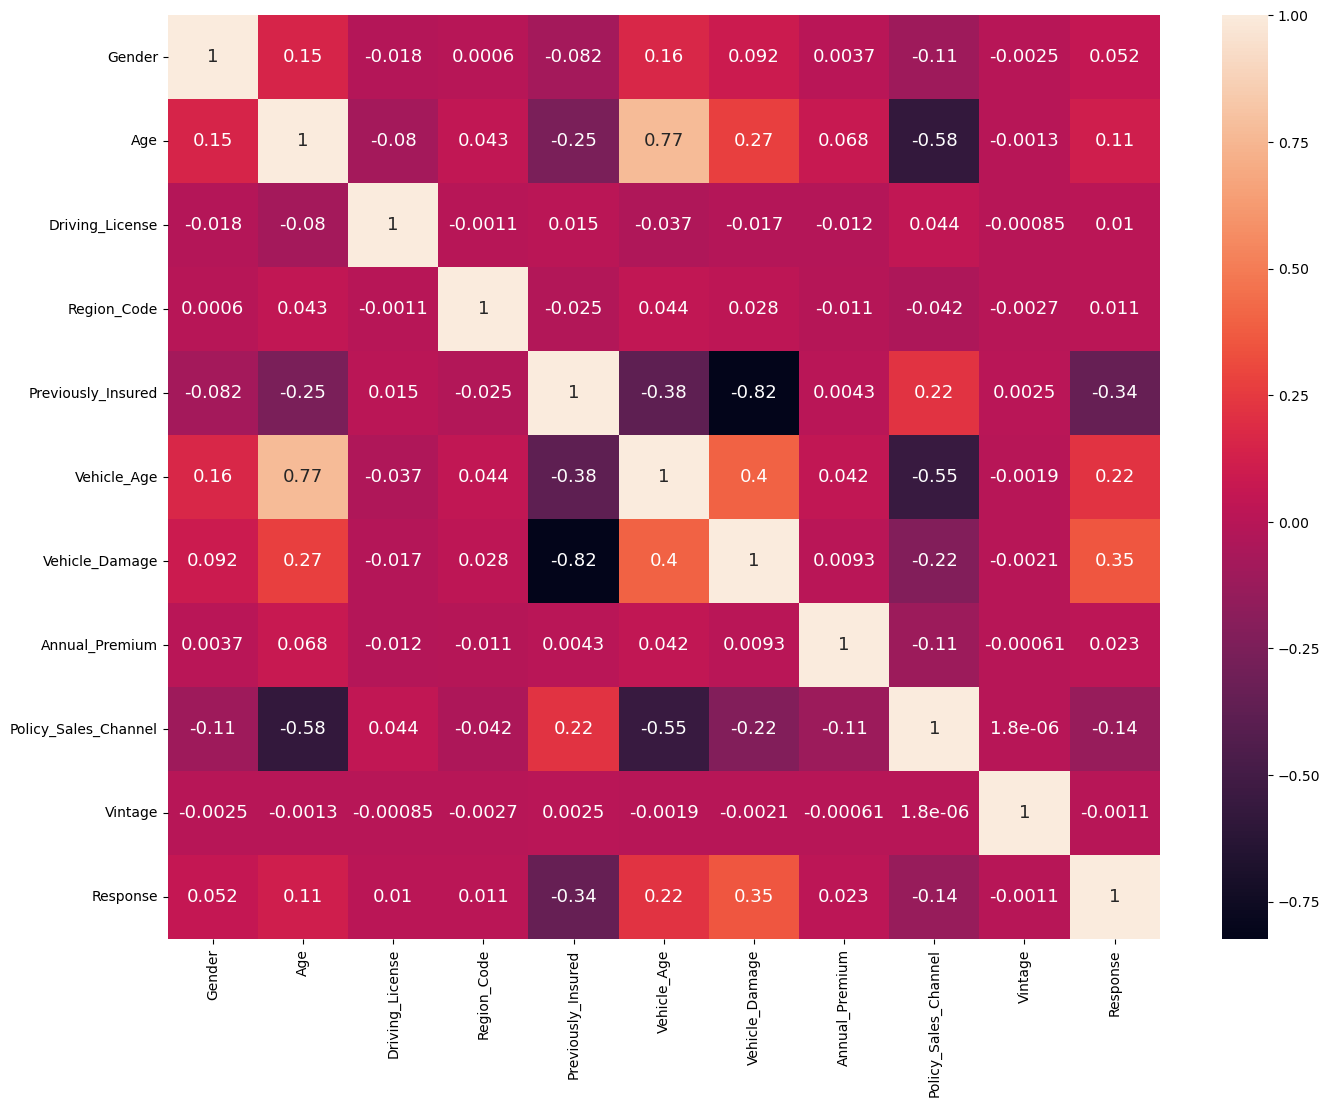

In [9]:
# Correlation Matrix
plt.figure(figsize=(16, 12))

hm = sns.heatmap(df.corr(),
                 yticklabels=df.columns,
                 xticklabels=df.columns,
                 annot=True,
                 annot_kws={'size':13})

plt.show()

Dalla matrice di correlazione si potrebbe valutare l'esclusione delle seguenti due variabili:
- Vintage, in quanto ha correlazione molto bassa rispetto a tutte le variabili, compresa quella target
- Previously_Insured, in quanto fortemente correlata rispetto alla variabile Vehicle_Damage

In [10]:
# df_w_features_selection = df.drop(["Vintage", "Previously_Insured"], axis=1)

Per il momento non eliminiamo nessuna variabile.

### **4 - Models Creation**
Come anticipato, la variabile target è una variabile dicotomica 1/0, inoltre abbiamo degli esempi di output. Si tratta quindi si un problema di classificazione.   
Anzitutto effettueremo una regressione logistica e verificheremo la bontà del modello.  
Dopo di che, applicheremo una tecnica di oversampling, SMOTE, che permette di aumentare in modo sintetico il numero di esempi appartenenti alla classe minoritaria, per verificare se le performance dei modelli migliorano.

Per prima cosa effettuiamo le seguenti tre operazioni:
- Divisione del dataframe tra features e variabile target
- Creazione dei training e testing set
- Standardizzazione dei dati (meglio normalizzazione)

In [11]:
# Features and target variable split
X = df.drop("Response", axis=1).values
y = df["Response"].values

# Training and testing set creation
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = .3, random_state = RANDOM_SEED)

print(f"{X_train.shape[0]} sono le righe relative alle features che formano il train set")
print(f"{X_test.shape[0]} sono le righe relative alle features che formano il train set")

print(f"{y_train.shape[0]} sono le righe relative alla variabile target che formano il train set")
print(f"{y_test.shape[0]} sono le righe relative alla variabile target che formano il train set")

unique, counts = np.unique(y, return_counts=True)
print(f"la var target ha {counts[0]} righe associate al valore 0 e {counts[1]} associate valore 1")

266776 sono le righe relative alle features che formano il train set
114333 sono le righe relative alle features che formano il train set
266776 sono le righe relative alla variabile target che formano il train set
114333 sono le righe relative alla variabile target che formano il train set
la var target ha 334399 righe associate al valore 0 e 46710 associate valore 1


In [12]:
#NORMALIZATION of X_train_resampled dataframe
norm = MinMaxScaler()

X_train = norm.fit_transform(X_train)
X_test = norm.transform(X_test)

In [13]:
# Logistic Regression Model
lr = LogisticRegression(class_weight = "balanced")
lr.fit(X_train, y_train)

LogisticRegression(class_weight='balanced')

Procediamo comunque con la creazione delle probabilità.
Da notare inoltre, come indicato nella documentazione ufficiale, che viene applicata di default la regolarizzazione L2.

In [14]:
y_pred_train = lr.predict(X_train)
y_proba_train = lr.predict_proba(X_train)

y_pred_test = lr.predict(X_test)
y_proba_test = lr.predict_proba(X_test)

Inoltre dato che, come espresso all'interno delle considerazioni iniziali, valutiamo maggiormente il peso di un falso negativo rispetto a un falso positivo, spostiamo il valore soglia in modo tale che la classificazione per i valori previsti di y_pred_train sia pari a 1 quando la probabilità di   y_proba_train è maggiore di 0.20, altrimenti 0.
In altre parole vogliamo minimizzare il numero dei casi di falsi negativi prodotti dal modello. Dato che la metrica di Recall sarà tanto più vicina a 1 quanto più basso sarà il numero di falsi negativi, l'obiettivo del modello sarà proprio quello di avere un valore di Recall quanto più vicino ad 1.

In [15]:
y_pred_train = np.where(y_proba_train[:,1]>0.20,1,0)
y_pred_test = np.where(y_proba_test[:,1]>0.20,1,0)

print(classification_report(y_train, y_pred_train))
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       1.00      0.56      0.72    233887
           1       0.24      0.99      0.39     32889

    accuracy                           0.61    266776
   macro avg       0.62      0.77      0.55    266776
weighted avg       0.90      0.61      0.68    266776

              precision    recall  f1-score   support

           0       1.00      0.56      0.72    100512
           1       0.24      0.99      0.38     13821

    accuracy                           0.61    114333
   macro avg       0.62      0.77      0.55    114333
weighted avg       0.90      0.61      0.68    114333



Vediamo tramite la matrice di confusione come performa il modello:

In [16]:
def plot_confusion_matrix(y_true, y_pred, labels = ["Negative", "Positive"], show_precision_recall = False):

    cm = confusion_matrix(y_true, y_pred)

    df_cm = pd.DataFrame(cm, index = labels,
                        columns = ["Predicted"+labels[0], "Predicted"+labels[1]])
    sns.heatmap(df_cm, annot= True, fmt = "g")

    if show_precision_recall:
        # Quale percentuale di classificazione positive erano effettivamente positive ?
        plt.text(0, -0.1, f"Precision: {(cm[1][1]/(cm[1][1]+cm[0][1])):.3f}")
        # Quale percentuale di osservazioni positive sono state classificate come positive ?
        plt.text(1, -0.1, f"Recall: {(cm[1][1]/(cm[1][1]+cm[1][0])):.3f}")

y_pred_train = np.where(y_proba_train[:,1]>0.25,1,0)

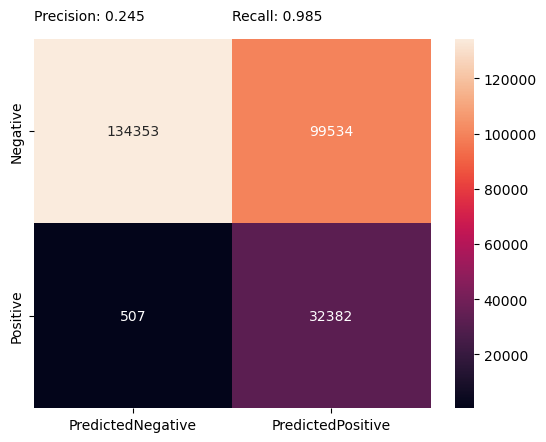

In [17]:
plot_confusion_matrix(y_train, y_pred_train, ["Negative", "Positive"], show_precision_recall = True)

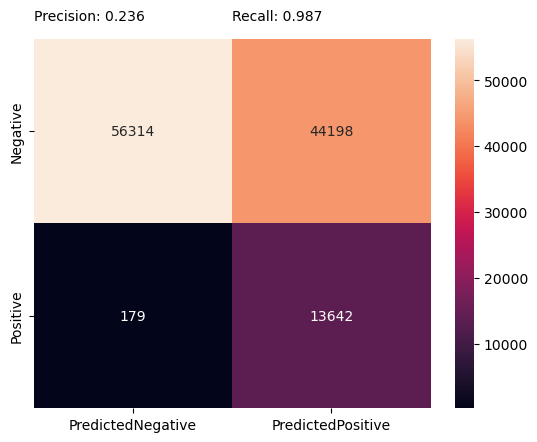

In [18]:
plot_confusion_matrix(y_test, y_pred_test, ["Negative", "Positive"], show_precision_recall = True)

Sia per il test set che per il train set i valori di precision e recall sono molto simili, in particolare il valore di recall è vicino a 1.
Creiamo inoltre la curva ROC, per visualizzare a livello grafico se il nostro modello è riuscito a stimare correttamente.

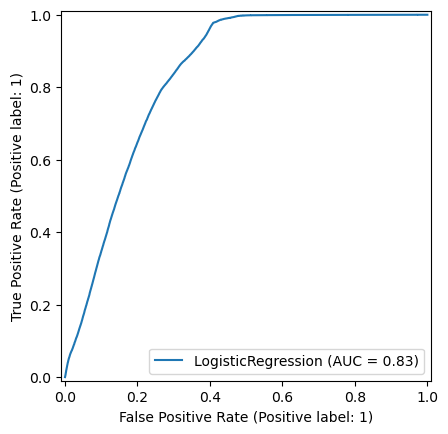

In [19]:
RocCurveDisplay.from_estimator(lr, X_train, y_train)

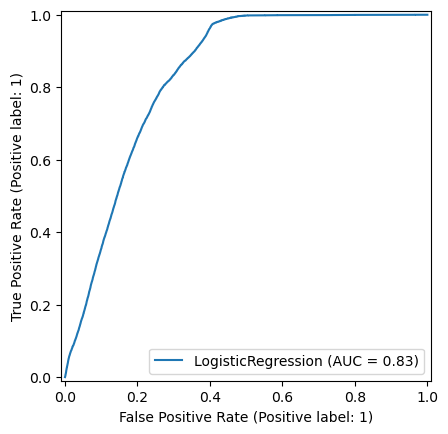

In [20]:
RocCurveDisplay.from_estimator(lr, X_test, y_test)

Dalla curva si evidenzia come sicuramente il modello, rispetto a un previsione casuale (che graficamente equivarebbe a tracciare una diagonale del quadrante), tenda a prevedere meglio.

Tenendo conto che la classe LogisticRegression() effettua di default una regolarizzazione l2.Proviamo a utilizzare anche la regolarizzazione l1, ovvero usando un modello Lasso,che ci permette di fare feature selection mandando a zero le variabili meno significative:

In [34]:
#Logistic Regression Model with Lasso regularization
penalty = 'l1'
C = 0.01
lr_l1 = LogisticRegression(class_weight = "balanced", penalty=penalty, C=C, solver = "liblinear")
lr_l1.fit(X_train, y_train)

LogisticRegression(C=0.01, class_weight='balanced', penalty='l1',
                   solver='liblinear')

In [32]:
y_pred_train = lr_l1.predict(X_train)
y_proba_train = lr_l1.predict_proba(X_train)

y_pred_test = lr_l1.predict(X_test)
y_proba_test = lr_l1.predict_proba(X_test)

In [33]:
y_pred_train = np.where(y_proba_train[:,1]>0.20,1,0)
y_pred_test = np.where(y_proba_test[:,1]>0.20,1,0)

print(classification_report(y_train, y_pred_train))
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       1.00      0.56      0.72    233887
           1       0.24      0.99      0.39     32889

    accuracy                           0.61    266776
   macro avg       0.62      0.77      0.55    266776
weighted avg       0.90      0.61      0.68    266776

              precision    recall  f1-score   support

           0       1.00      0.56      0.72    100512
           1       0.24      0.99      0.38     13821

    accuracy                           0.61    114333
   macro avg       0.62      0.77      0.55    114333
weighted avg       0.90      0.61      0.68    114333



L'utilizzo della regolarizzazione Lasso non ha sostanzialmente portato a nessuna differenza rispetto alla regolarizzazione Ridge.

Infine, proviamo a migliorare i risultati effettuando un bilanciamento delle classi, ovvero applicando un metodo di oversampling tramite SMOTE, il cui scopo è proprio quelli di ribilanciare la distribuzione delle classi attraverso una replica casuale degli esempi appartenenti alla classe minore, in modo tale che alla fine il numero di esempi sia lo stesso della classe più frequente.

In [24]:
print("Before OverSampling, counts of label '1': {}".format(sum(y_train == 1))) 
print("Before OverSampling, counts of label '0': {} \n".format(sum(y_train == 0)))

sm = SMOTE(random_state=2)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print('After OverSampling, the shape of train_X: {}'.format(X_train_res.shape)) 
print('After OverSampling, the shape of train_y: {} \n'.format(y_train_res.shape)) 
  
print("After OverSampling, counts of label '1': {}".format(sum(y_train_res == 1))) 
print("After OverSampling, counts of label '0': {}".format(sum(y_train_res == 0))) 

Before OverSampling, counts of label '1': 32889
Before OverSampling, counts of label '0': 233887 

After OverSampling, the shape of train_X: (467774, 10)
After OverSampling, the shape of train_y: (467774,) 

After OverSampling, counts of label '1': 233887
After OverSampling, counts of label '0': 233887


In [25]:
lr1 = LogisticRegression()
lr1.fit(X_train_res, y_train_res)
y_pred_test = lr1.predict(X_test)

In [26]:
# print classification report
y_pred_test = np.where(y_proba_test[:,1]>0.20,1,0)
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       1.00      0.56      0.72    100512
           1       0.23      0.99      0.38     13821

    accuracy                           0.61    114333
   macro avg       0.62      0.77      0.55    114333
weighted avg       0.90      0.61      0.67    114333



Anche tramite il bilanciamento non ci sono variazioni significative sulle metriche.  
In conclusione, tra i vari modelli che abbiamo esaminato non esistono significative differenze per le metriche. Il valore del recall - che è fondamentale nella nostra casistica - in particolare risulta essere piuttosto alto (0.99). Va comunque considerato che il modello non è perfetto e non riesce comunque a "catturare" tutti i clienti che avrebbero risposto positivamente all'offerta assicurativa: l'azienda, prima di utilizzare il modello, dovrà fare una valutazione confrontando il mancato guadagno legato ai clienti che non hanno acquistato il prodotto con il costo che avrebbe sostenuto se avesse inviato l'offerta a tutti i clienti. Se il mancato guadagno fosse maggiore, infatti, allora converebbe inviare l'offerta a tutti i clienti o, alternativamente, proseguire l'analisi ottenendo un modello che sia in grado di ridurre il numero dei casi di falsi positivi (aumentando cioè la precision del modello) mantenendo sostanzialmente invariato quello dei falsi negativi, fino a rendere conveniente l'applicazione del modello stesso. Se invece il mancato guadagno fosse monore, l'applicazione di questo modello porterebbe già un guadagno all'azienda.